# Лабораторна 3. Класифікація зображень (CNN)
### Шальман Тимофій КА-35

## Варіант 15 (Tiny ImageNet - 200 класів)

In [1]:
import pandas as pd

splits = {
    'train': 'data/train-00000-of-00001-1359597a978bc4fa.parquet', 
    'valid': 'data/valid-00000-of-00001-70d52db3c749a935.parquet'
    }

df_train = pd.read_parquet("hf://datasets/zh-plus/tiny-imagenet/" + splits["train"])
df_valid = pd.read_parquet("hf://datasets/zh-plus/tiny-imagenet/" + splits["valid"])

In [2]:
df_train.shape, df_valid.shape

((100000, 2), (10000, 2))

In [3]:
df_train.head()

,image,label
0,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,0
1,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,0
2,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,0
3,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,0
4,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,0


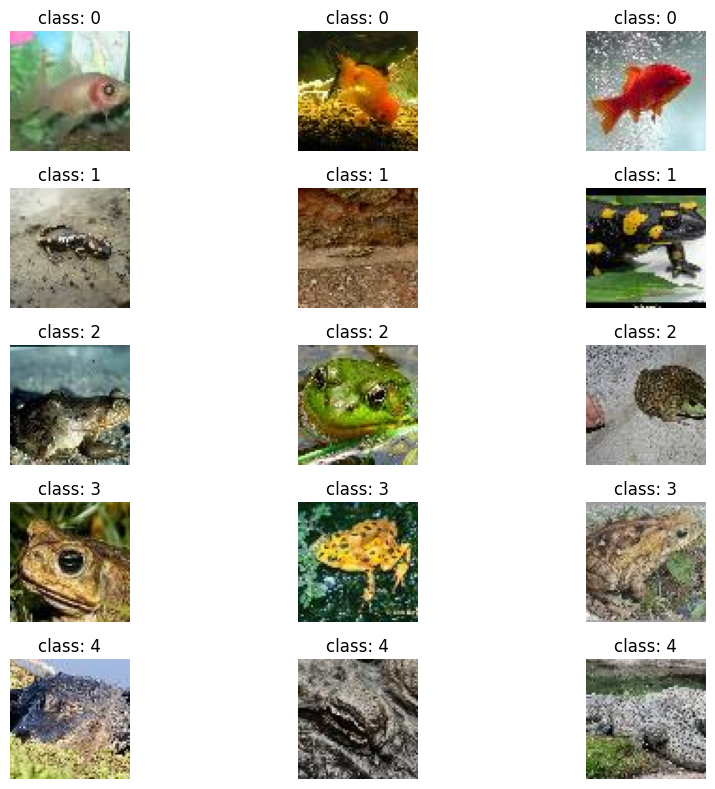

In [4]:
import matplotlib.pyplot as plt
from PIL import Image
import io

classes = sorted(df_train["label"].unique())[:5]

plt.figure(figsize=(10, 8))
plot_idx = 1

for cls in classes:
    samples = df_train[df_train["label"] == cls].head(3)
    
    for _, row in samples.iterrows():
        img_dict = row["image"]
        
        # беремо bytes з dict
        image = Image.open(io.BytesIO(img_dict["bytes"])).convert("RGB")
        
        plt.subplot(len(classes), 3, plot_idx)
        plt.imshow(image)
        plt.title(f"class: {cls}")
        plt.axis("off")
        
        plot_idx += 1

plt.tight_layout()
plt.show()

### Dataset клас

In [5]:
import torch
from torch.utils.data import Dataset
import numpy as np
from PIL import Image
import io

class TinyImageNetDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        
        label = row['label']
        image_bytes = row['image']["bytes"]
        image = Image.open(io.BytesIO(image_bytes)).convert('RGB')
        
        if self.transform:
            image = self.transform(image)

        return image, label

### Аугментації

In [6]:
from torchvision import transforms

transform = transforms.Compose([
    transforms.RandomResizedCrop(64),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.2, 0.2, 0.2, 0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3),
])

valid_tfms = transforms.Compose([
    transforms.Resize(64),
    transforms.CenterCrop(64),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3),
])

### DataLoader

In [7]:
from torch.utils.data import DataLoader

train_dataset = TinyImageNetDataset(df_train, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

valid_dataset = TinyImageNetDataset(df_valid, transform=valid_tfms)
valid_loader = DataLoader(valid_dataset, batch_size=64, shuffle=False)

## Тренування моделі ResNet18

In [8]:
import torchvision.models as models
import torch.nn as nn

model = models.resnet18(weights=None)
model.fc = nn.Linear(model.fc.in_features, 200)

In [9]:
model

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [10]:
from tqdm import tqdm

def train_one_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    
    total_loss = 0
    correct_top1 = 0
    correct_top5 = 0
    total = 0

    pbar = tqdm(dataloader, desc="Train", leave=False)

    for x, y in pbar:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        outputs = model(x)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        # Top-1
        _, pred = outputs.max(1)
        correct_top1 += (pred == y).sum().item()

        # Top-5
        _, top5 = outputs.topk(5, dim=1)
        correct_top5 += (top5 == y.view(-1, 1)).sum().item()

        total += y.size(0)

        lr = optimizer.param_groups[0]['lr']

        pbar.set_postfix({
            "loss": total_loss / (total / y.size(0)),
            "top1": correct_top1 / total,
            "top5": correct_top5 / total,
            "lr": lr
        })

    return {
        "loss": total_loss / len(dataloader),
        "top1": correct_top1 / total,
        "top5": correct_top5 / total
    }

In [11]:
from sklearn.metrics import f1_score, confusion_matrix

def evaluate(model, dataloader, criterion, device):
    model.eval()

    total_loss = 0
    correct_top1 = 0
    correct_top5 = 0
    total = 0

    all_preds = []
    all_targets = []

    pbar = tqdm(dataloader, desc="Eval", leave=False)

    with torch.no_grad():
        for x, y in pbar:
            x, y = x.to(device), y.to(device)

            outputs = model(x)
            loss = criterion(outputs, y)

            total_loss += loss.item()

            # Top-1
            _, pred = outputs.max(1)
            correct_top1 += (pred == y).sum().item()

            # Top-5
            _, top5 = outputs.topk(5, dim=1)
            correct_top5 += (top5 == y.view(-1, 1)).sum().item()

            total += y.size(0)

            all_preds.extend(pred.cpu().numpy())
            all_targets.extend(y.cpu().numpy())

            pbar.set_postfix({
                "loss": total_loss / (total / y.size(0)),
                "top1": correct_top1 / total,
                "top5": correct_top5 / total
            })

    f1 = f1_score(all_targets, all_preds, average="macro")
    cm = confusion_matrix(all_targets, all_preds)

    return {
        "loss": total_loss / len(dataloader),
        "top1": correct_top1 / total,
        "top5": correct_top5 / total,
        "f1": f1,
        "confusion_matrix": cm
    }

In [ ]:
import os

# Директорія для збереження моделі
save_dir = "./models/resnet18"
os.makedirs(save_dir, exist_ok=True)

### Тренування з Cosine Scheduler

In [ ]:
from torch.optim.lr_scheduler import CosineAnnealingLR


device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

print(f"device: {device}")

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters())

num_epochs = 10

scheduler = CosineAnnealingLR(
    optimizer,
    T_max=num_epochs,
    eta_min=1e-5  # мінімальний LR
)

history = {
    "train_loss": [],
    "val_loss": [],
    "train_top1": [],
    "val_top1": [],
}

for epoch in range(num_epochs):
    train_metrics = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_metrics = evaluate(model, valid_loader, criterion, device)

    scheduler.step()
   
    history["train_loss"].append(train_metrics["loss"])
    history["val_loss"].append(val_metrics["loss"])
    history["train_top1"].append(train_metrics["top1"])
    history["val_top1"].append(val_metrics["top1"])

    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"Train Loss: {train_metrics['loss']:.4f} | Top1: {train_metrics['top1']:.4f} | Top5: {train_metrics['top5']:.4f}")
    print(f"Val   Loss: {val_metrics['loss']:.4f} | Top1: {val_metrics['top1']:.4f} | Top5: {val_metrics['top5']:.4f} | F1: {val_metrics['f1']:.4f}")

# Збереження моделі
torch.save(model.state_dict(), f"{save_dir}/tl_resnet18.pth")

device: cuda


Epoch 1/10
Train Loss: 4.8308 | Top1: 0.0411 | Top5: 0.1427
Val   Loss: 4.3092 | Top1: 0.0900 | Top5: 0.2675 | F1: 0.0611


Epoch 2/10
Train Loss: 4.3209 | Top1: 0.0943 | Top5: 0.2686
Val   Loss: 4.0253 | Top1: 0.1370 | Top5: 0.3526 | F1: 0.1094


Epoch 3/10
Train Loss: 4.0359 | Top1: 0.1355 | Top5: 0.3404
Val   Loss: 3.6717 | Top1: 0.1846 | Top5: 0.4382 | F1: 0.1600


Epoch 4/10
Train Loss: 3.8264 | Top1: 0.1700 | Top5: 0.3898
Val   Loss: 3.7283 | Top1: 0.1926 | Top5: 0.4269 | F1: 0.1742


...

Epoch 6/10
Train Loss: 3.4850 | Top1: 0.2241 | Top5: 0.4688
Val   Loss: 3.2134 | Top1: 0.2700 | Top5: 0.5302 | F1: 0.2511


Epoch 7/10
Train Loss: 3.3527 | Top1: 0.2482 | Top5: 0.4993
Val   Loss: 3.0347 | Top1: 0.3002 | Top5: 0.5654 | F1: 0.2856


Epoch 8/10
Train Loss: 3.2262 | Top1: 0.2696 | Top5: 0.5264
Val   Loss: 2.9893 | Top1: 0.3104 | Top5: 0.5822 | F1: 0.2981


Epoch 9/10
Train Loss: 3.1337 | Top1: 0.2857 | Top5: 0.5451
Val   Loss: 2.9485 | Top1: 0.3215 | Top5: 0.5917 | F1: 0.3071


Epoch 10/10
Train Loss: 3.0759 | Top1: 0.2979 | Top5: 0.5552
Val   Loss: 2.9124 | Top1: 0.3252 | Top5: 0.5960 | F1: 0.3115


### Результати

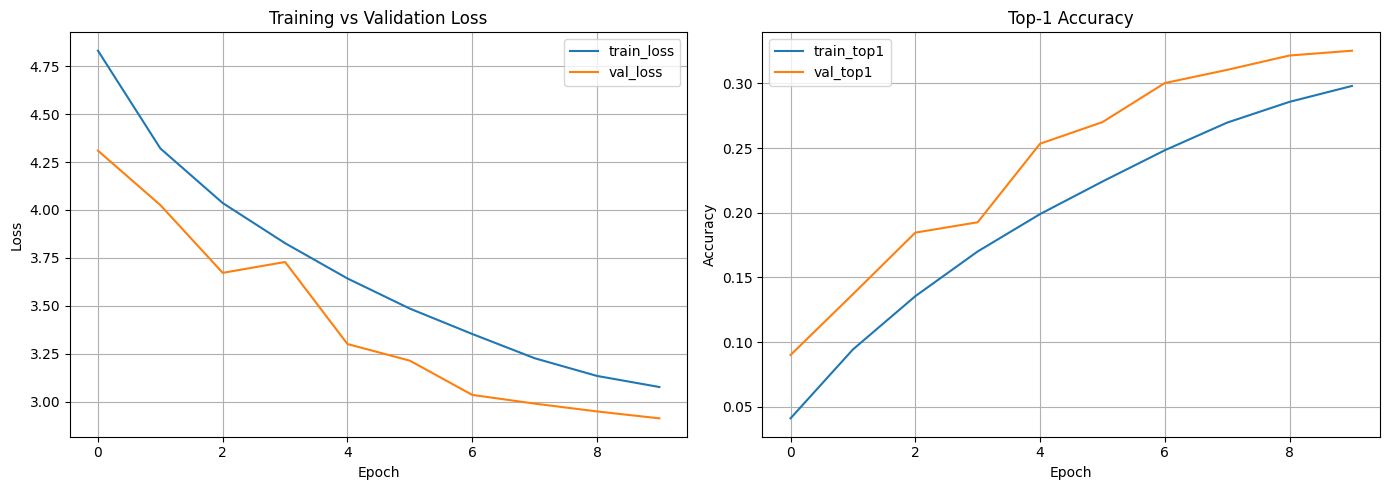

In [13]:
plt.figure(figsize=(14,5))

# Графік loss
plt.subplot(1, 2, 1)
plt.plot(history["train_loss"], label="train_loss")
plt.plot(history["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid()

# Графік accuracy
plt.subplot(1, 2, 2)
plt.plot(history["train_top1"], label="train_top1")
plt.plot(history["val_top1"], label="val_top1")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Top-1 Accuracy")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

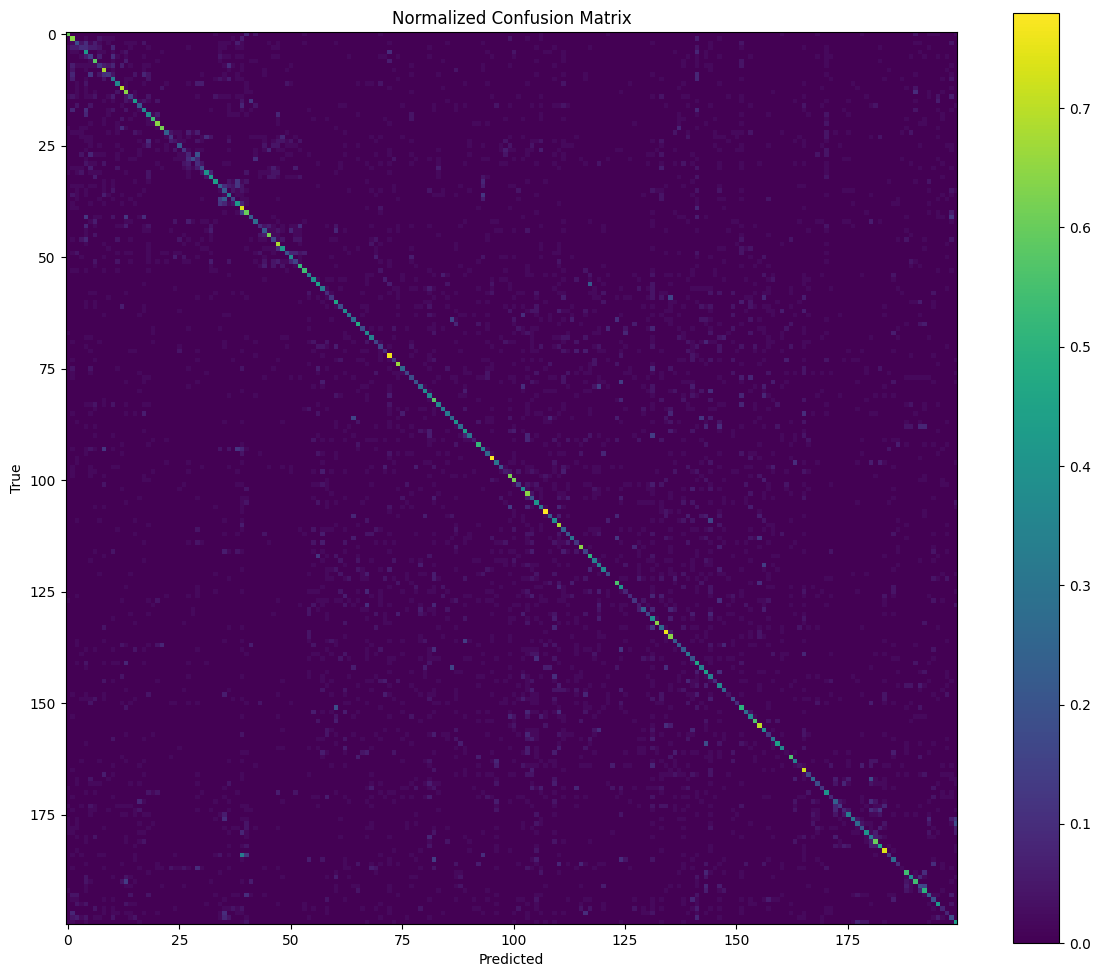

In [14]:
cm = val_metrics["confusion_matrix"]

# нормалізація по рядках (true labels)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(12, 10))
plt.imshow(cm_norm, interpolation='nearest')
plt.title("Normalized Confusion Matrix")
plt.colorbar()

plt.xlabel("Predicted")
plt.ylabel("True")

plt.tight_layout()
plt.show()

### Grad-CAM

In [15]:
target_layer = model.layer4

In [17]:
def compute_heatmap(model, img):
    model.eval()

    activations = []
    gradients = []

    # hook для збереження активацій
    def forward_hook(module, input, output):
        activations.append(output)

    # hook для градієнтів
    def backward_hook(module, grad_input, grad_output):
        gradients.append(grad_output[0])

    # реєструємо hooks
    handle_f = target_layer.register_forward_hook(forward_hook)
    handle_b = target_layer.register_backward_hook(backward_hook)

    # forward
    logits = model(img)
    pred = logits.argmax(dim=1)

    # backward по predicted класу
    model.zero_grad()
    logits[0, pred].backward()

    # отримуємо активації і градієнти
    acts = activations[0]
    grads = gradients[0]

    # global average pooling градієнтів
    weights = grads.mean(dim=(2, 3), keepdim=True)

    # зважена сума
    heatmap = (weights * acts).sum(dim=1)[0]

    # ReLU
    heatmap = torch.relu(heatmap)

    # нормалізація
    heatmap = heatmap / (heatmap.max() + 1e-8)

    # очищаємо hooks
    handle_f.remove()
    handle_b.remove()

    return heatmap.detach().cpu(), pred.item()

In [18]:
import cv2
import numpy as np

def upsampleHeatmap(heatmap, image):
    heatmap = heatmap.numpy()

    # resize до розміру картинки
    heatmap = cv2.resize(heatmap, (image.shape[2], image.shape[3]))

    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    # tensor → numpy
    img = image[0].cpu().permute(1, 2, 0).numpy()

    # денормалізація
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = std * img + mean
    img = np.clip(img, 0, 1)

    img = np.uint8(255 * img)

    # overlay
    overlay = cv2.addWeighted(img, 0.5, heatmap, 0.5, 0)

    return overlay

In [19]:
import matplotlib.pyplot as plt

def display_images(overlay, image):
    img = image[0].cpu().permute(1, 2, 0).numpy()

    plt.figure(figsize=(10,5))

    plt.subplot(1,2,1)
    plt.imshow(overlay)
    plt.title("Grad-CAM")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(img)
    plt.title("Original")
    plt.axis("off")

    plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].


Pred: 109, True: 152


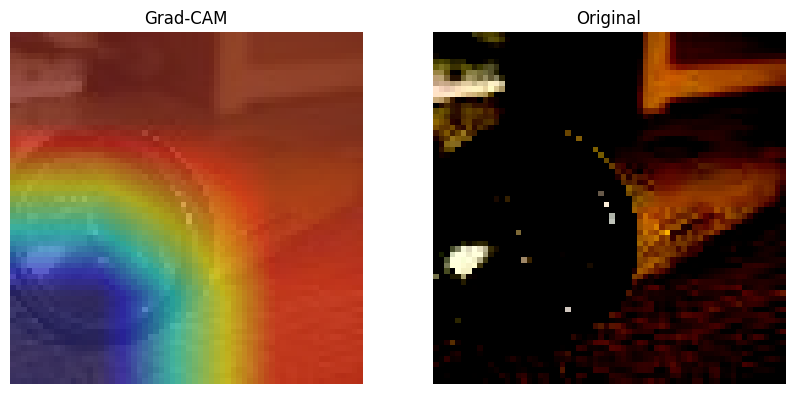

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].


Pred: 150, True: 150


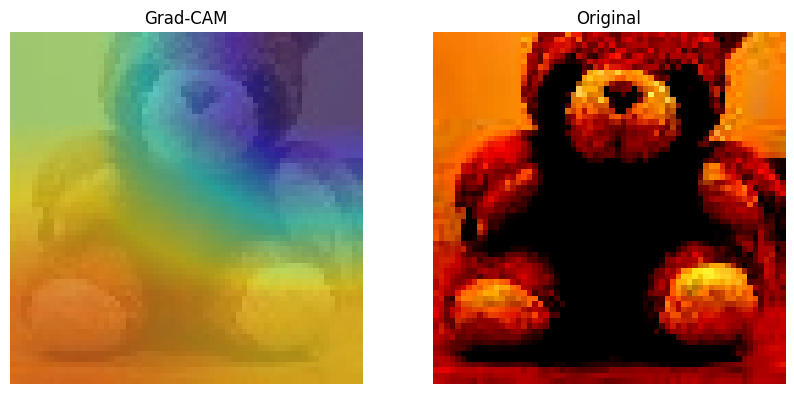

Pred: 21, True: 21


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.7882353..0.9843137].


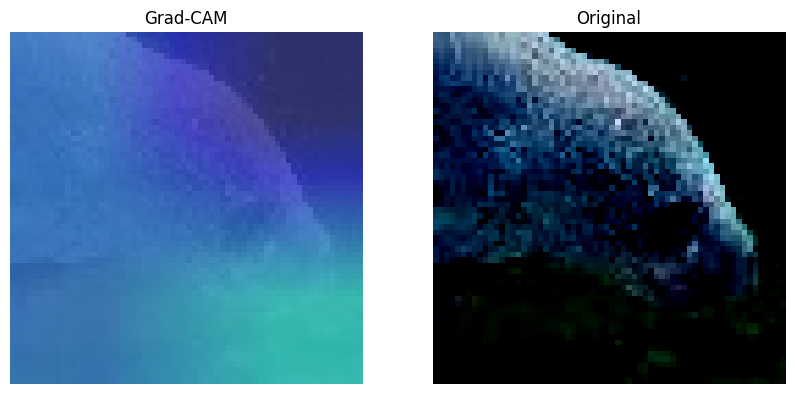

Pred: 50, True: 44


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].


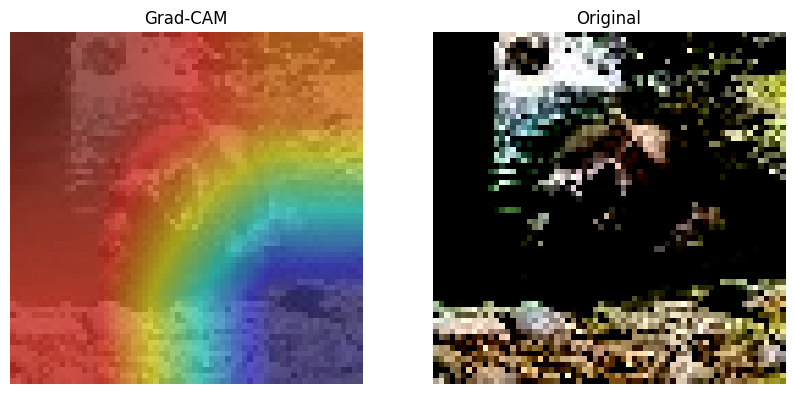

In [22]:
import random

model.eval()

for _ in range(4):  # 4 випадкові приклади
    idx = random.randint(0, len(valid_dataset) - 1)

    img, label = valid_dataset[idx]
    img = img.unsqueeze(0).to(device)

    heatmap, pred = compute_heatmap(model, img)
    overlay = upsampleHeatmap(heatmap, img)

    print(f"Pred: {pred}, True: {label}")

    display_images(overlay, img)

## Transfer learning ResNet18

In [8]:
import torchvision.models as models
import torch.nn as nn

model = models.resnet18(weights="IMAGENET1K_V1")
model.fc = nn.Linear(model.fc.in_features, 200)

In [9]:
for param in model.parameters():
    param.requires_grad = False

# розморожуємо тільки останній шар
for param in model.fc.parameters():
    param.requires_grad = True

In [27]:
model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.fc.parameters(), lr=1e-3)

In [28]:
# ImageNet нормалізація

train_tfms = transforms.Compose([
    transforms.RandomResizedCrop(64),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])

valid_tfms = transforms.Compose([
    transforms.Resize(64),
    transforms.CenterCrop(64),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])

In [29]:
train_dataset = TinyImageNetDataset(df_train, transform=train_tfms)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

valid_dataset = TinyImageNetDataset(df_valid, transform=valid_tfms)
valid_loader = DataLoader(valid_dataset, batch_size=64, shuffle=False)

In [12]:
import os

# Директорія для збереження моделі
save_dir = "./models/resnet18"
os.makedirs(save_dir, exist_ok=True)

In [14]:
from torch.optim.lr_scheduler import CosineAnnealingLR


device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

print(f"device: {device}")

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters())

num_epochs = 10

scheduler = CosineAnnealingLR(
    optimizer,
    T_max=num_epochs,
    eta_min=1e-5  # мінімальний LR
)

history = {
    "train_loss": [],
    "val_loss": [],
    "train_top1": [],
    "val_top1": [],
}

for epoch in range(num_epochs):
    train_metrics = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_metrics = evaluate(model, valid_loader, criterion, device)

    scheduler.step()
   
    history["train_loss"].append(train_metrics["loss"])
    history["val_loss"].append(val_metrics["loss"])
    history["train_top1"].append(train_metrics["top1"])
    history["val_top1"].append(val_metrics["top1"])

    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"Train Loss: {train_metrics['loss']:.4f} | Top1: {train_metrics['top1']:.4f} | Top5: {train_metrics['top5']:.4f}")
    print(f"Val   Loss: {val_metrics['loss']:.4f} | Top1: {val_metrics['top1']:.4f} | Top5: {val_metrics['top5']:.4f} | F1: {val_metrics['f1']:.4f}")

# Збереження моделі
torch.save(model.state_dict(), f"{save_dir}/tl_resnet18.pth")

device: cuda


Epoch 1/10
Train Loss: 3.8345 | Top1: 0.2067 | Top5: 0.4255
Val   Loss: 3.3459 | Top1: 0.2952 | Top5: 0.5548 | F1: 0.2882


Epoch 2/10
Train Loss: 3.5716 | Top1: 0.2440 | Top5: 0.4864
Val   Loss: 3.3680 | Top1: 0.3016 | Top5: 0.5637 | F1: 0.2971


Epoch 3/10
Train Loss: 3.5141 | Top1: 0.2552 | Top5: 0.4973
Val   Loss: 3.2983 | Top1: 0.3134 | Top5: 0.5722 | F1: 0.3085


Epoch 4/10
Train Loss: 3.4733 | Top1: 0.2592 | Top5: 0.5060
Val   Loss: 3.2910 | Top1: 0.3184 | Top5: 0.5759 | F1: 0.3145


...

Epoch 6/10
Train Loss: 3.3774 | Top1: 0.2728 | Top5: 0.5197
Val   Loss: 3.1581 | Top1: 0.3320 | Top5: 0.5865 | F1: 0.3276


Epoch 7/10
Train Loss: 3.3143 | Top1: 0.2814 | Top5: 0.5299
Val   Loss: 3.1027 | Top1: 0.3353 | Top5: 0.5994 | F1: 0.3289


Epoch 8/10
Train Loss: 3.2766 | Top1: 0.2867 | Top5: 0.5367
Val   Loss: 3.0915 | Top1: 0.3366 | Top5: 0.5983 | F1: 0.3310


Epoch 9/10
Train Loss: 3.2370 | Top1: 0.2939 | Top5: 0.5443
Val   Loss: 3.0547 | Top1: 0.3454 | Top5: 0.6066 | F1: 0.3388


Epoch 10/10
Train Loss: 3.2252 | Top1: 0.2950 | Top5: 0.5463
Val   Loss: 3.0487 | Top1: 0.3430 | Top5: 0.6023 | F1: 0.3375


### Результати

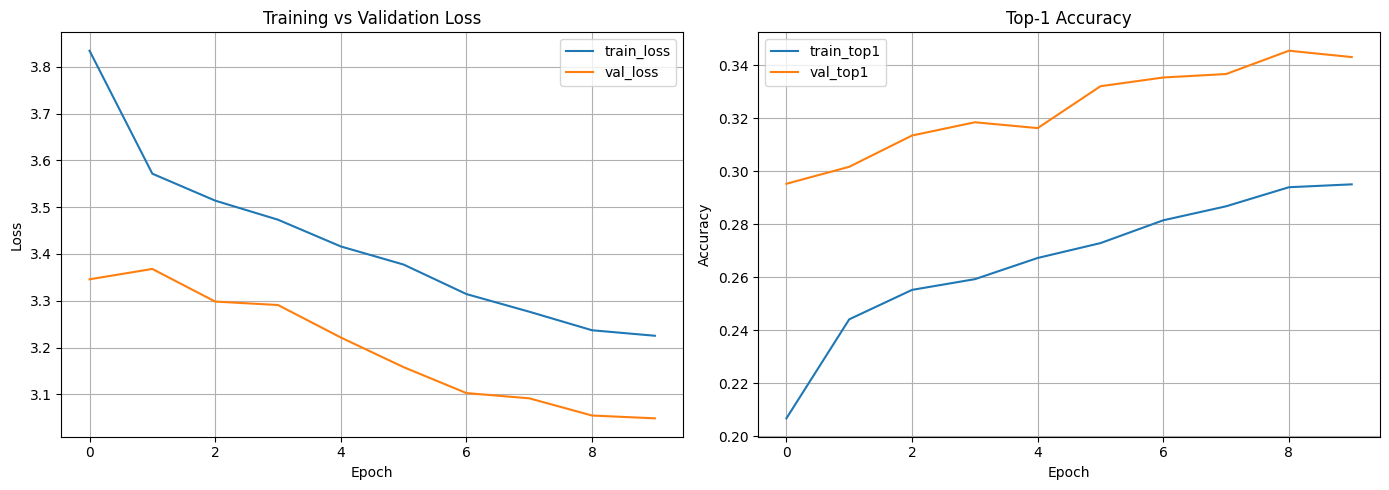

In [15]:
plt.figure(figsize=(14,5))

# Графік loss
plt.subplot(1, 2, 1)
plt.plot(history["train_loss"], label="train_loss")
plt.plot(history["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid()

# Графік accuracy
plt.subplot(1, 2, 2)
plt.plot(history["train_top1"], label="train_top1")
plt.plot(history["val_top1"], label="val_top1")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Top-1 Accuracy")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

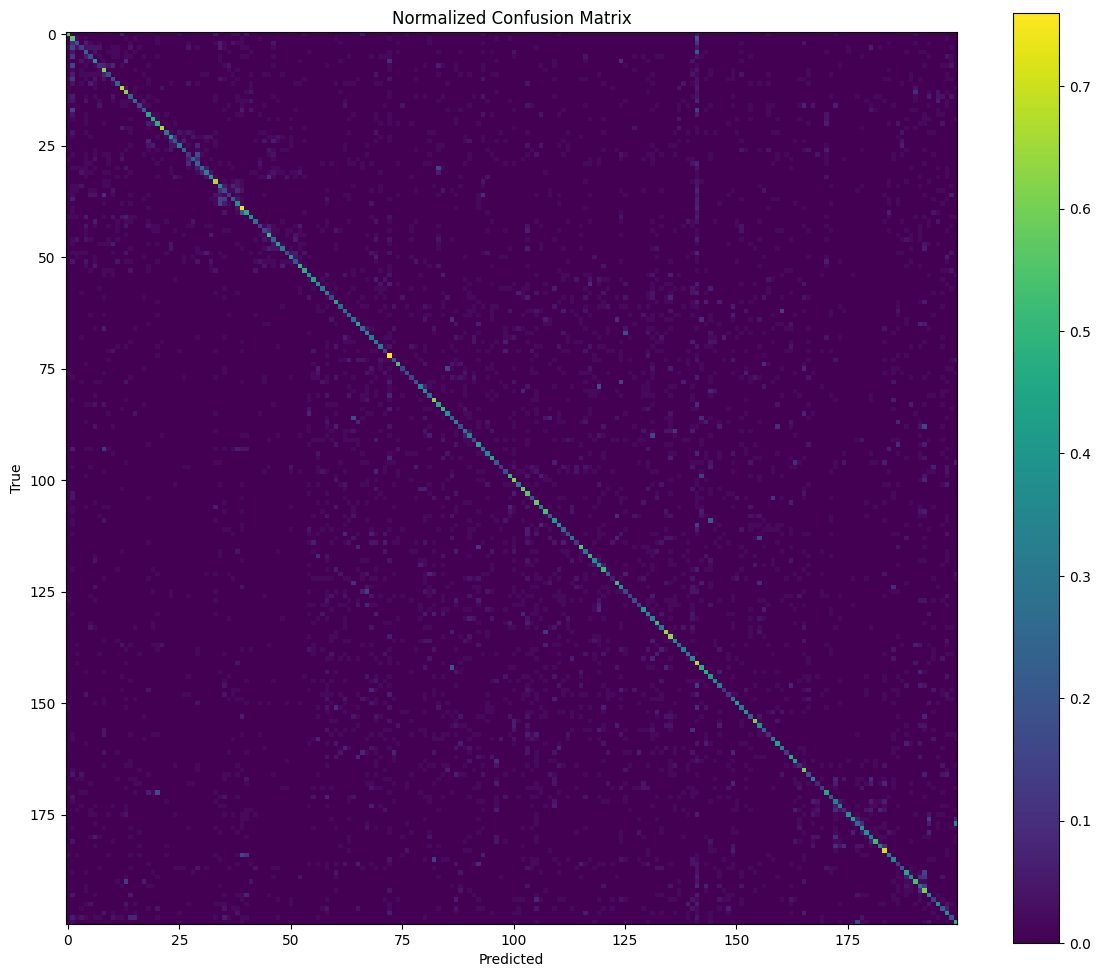

In [16]:
cm = val_metrics["confusion_matrix"]

# нормалізація по рядках (true labels)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(12, 10))
plt.imshow(cm_norm, interpolation='nearest')
plt.title("Normalized Confusion Matrix")
plt.colorbar()

plt.xlabel("Predicted")
plt.ylabel("True")

plt.tight_layout()
plt.show()

### Grad-CAM

In [32]:
target_layer = model.layer4[-1].conv2

In [33]:
def compute_heatmap(model, img):
    model.eval()

    img = img.clone().detach().requires_grad_(True)

    activations = []
    gradients = []

    def forward_hook(module, input, output):
        activations.append(output)

    def backward_hook(module, grad_input, grad_output):
        gradients.append(grad_output[0])

    handle_f = target_layer.register_forward_hook(forward_hook)
    handle_b = target_layer.register_full_backward_hook(backward_hook)

    logits = model(img)
    pred = logits.argmax(dim=1).item()

    model.zero_grad(set_to_none=True)
    logits[0, pred].backward()

    if len(activations) == 0 or len(gradients) == 0:
        handle_f.remove()
        handle_b.remove()
        raise RuntimeError("Hooks did not capture activations/gradients. Check target_layer.")

    acts = activations[0]
    grads = gradients[0]

    weights = grads.mean(dim=(2, 3), keepdim=True)
    heatmap = (weights * acts).sum(dim=1)[0]
    heatmap = torch.relu(heatmap)
    heatmap = heatmap / (heatmap.max() + 1e-8)

    handle_f.remove()
    handle_b.remove()

    return heatmap.detach().cpu(), pred

/home/tym/kpi/neural_networks/nn_Lab3-4/.venv/lib/python3.12/site-packages/torch/nn/modules/module.py:1870: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].


Pred: 38, True: 93


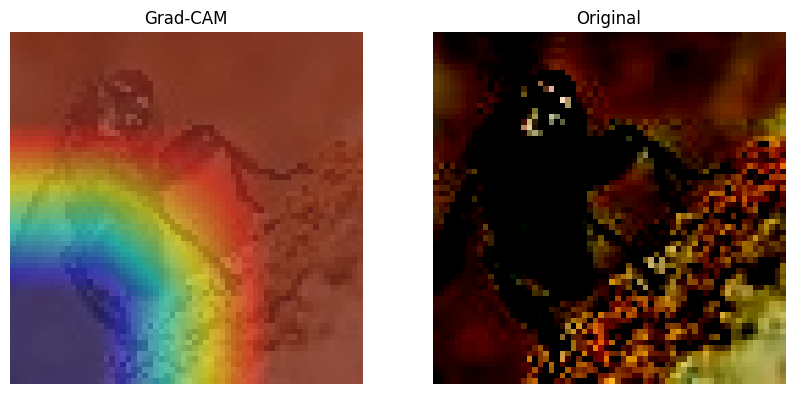

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].


Pred: 138, True: 138


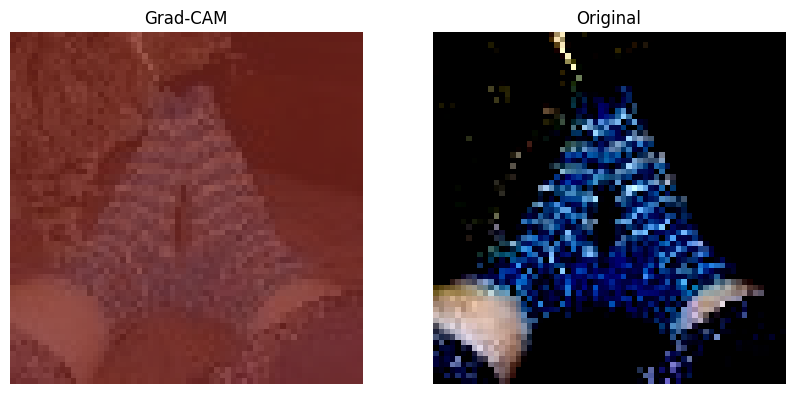

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.6627451..1.0].


Pred: 101, True: 66


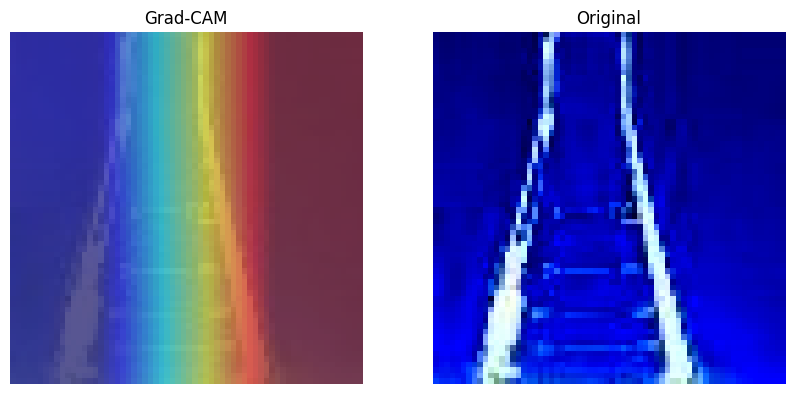

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.99215686].


Pred: 154, True: 154


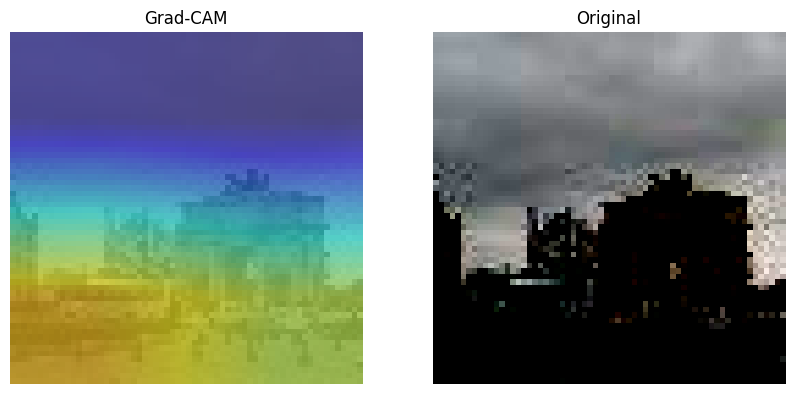

In [34]:
import random

model.eval()

for _ in range(4):  # 4 випадкові приклади
    idx = random.randint(0, len(valid_dataset) - 1)

    img, label = valid_dataset[idx]
    img = img.unsqueeze(0).to(device)

    heatmap, pred = compute_heatmap(model, img)
    overlay = upsampleHeatmap(heatmap, img)

    print(f"Pred: {pred}, True: {label}")

    display_images(overlay, img)

### Порівняння моделей: навчання з нуля vs transfer learning (ResNet18)

**Результати (10 епох):**

| Підхід             | Top-1 (val) | Top-5 (val) | F1 (val)   |
| ------------------ | ----------- | ----------- | ---------- |
| З нуля             | 0.3252      | 0.5960      | 0.3115     |
| Transfer learning  | **0.3454**  | **0.6066**  | **0.3388** |

* У цьому випадку **transfer learning** показав **кращі результати** за всіма метриками.
* Модель із попередньо навченими вагами вже мала корисні ознаки (features), отримані з великого датасету (ImageNet), що дало кращий старт.
* Навіть при навчанні лише фінального шару модель змогла ефективно адаптуватися до задачі.

**Динаміка навчання:**

* **Transfer learning** одразу дає високі результати вже з 1-ї епохи (Top-1 ≈ 0.29), тоді як модель “з нуля” стартує значно гірше (≈ 0.09).
* Модель, навчена **з нуля**, демонструє стабільний прогрес, але за 10 епох не встигає наздогнати TL.
* TL досягає плато швидше, але все ще трохи покращується до ~9-ї епохи.

**Висновки:**

* Transfer learning у форматі “freeze + fc” виявився **ефективнішим** для цієї задачі.
* Основна перевага - **швидка збіжність і краща якість на малому числі епох**.
* Навчання з нуля має потенціал, але потребує:
  - більшої кількості епох  
  - кращої оптимізації
* Для подальшого покращення TL варто застосувати:
  - **fine-tuning (розморожування частини шарів, наприклад)**  
  - менший learning rate для базових шарів